<style>
body, .jp-Notebook {
  background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%) !important;
  min-height: 100vh;
}
.jp-Cell, .jp-CodeCell, .jp-MarkdownCell {
  background: rgba(255,255,255,0.04) !important;
  border: 1px solid rgba(0,180,216,0.2) !important;
  border-radius: 10px !important;
  margin-bottom: 14px !important;
}
.jp-MarkdownOutput h1 { color: #e94560; border-bottom: 2px solid #e94560; padding-bottom: 8px; font-size: 2em; }
.jp-MarkdownOutput h2 { color: #00b4d8; border-left: 4px solid #00b4d8; padding-left: 10px; }
.jp-MarkdownOutput h3 { color: #90e0ef; }
.jp-MarkdownOutput p, .jp-MarkdownOutput li { color: #ccd6f6; line-height: 1.8; }
.jp-MarkdownOutput code { background: rgba(233,69,96,0.15); border: 1px solid #e94560; border-radius: 4px; padding: 2px 6px; color: #e94560; }
.jp-MarkdownOutput pre { background: rgba(0,0,0,0.4); border: 1px solid #0f3460; border-left: 4px solid #00b4d8; border-radius: 8px; padding: 16px; }
.jp-MarkdownOutput pre code { background: none; border: none; color: #a8dadc; padding: 0; }
.jp-MarkdownOutput blockquote { border-left: 4px solid #e94560; background: rgba(233,69,96,0.08); padding: 12px 20px; border-radius: 0 8px 8px 0; color: #ccd6f6; }
.jp-MarkdownOutput table { width: 100%; border-collapse: collapse; }
.jp-MarkdownOutput th { background: rgba(0,180,216,0.2); color: #00b4d8; padding: 10px 14px; border: 1px solid #0f3460; }
.jp-MarkdownOutput td { padding: 8px 14px; border: 1px solid #0f3460; color: #ccd6f6; }
.jp-MarkdownOutput tr:nth-child(even) td { background: rgba(255,255,255,0.03); }
.CodeMirror, .cm-editor { background: #0d1117 !important; color: #c9d1d9 !important; }
.jp-InputArea-editor { background: #0d1117 !important; border-radius: 6px !important; }
</style>

# Facial Emotion Recognition with MobileNetV2

> A deep learning pipeline for classifying facial expressions into 5 emotion categories using transfer learning on the FER2013 dataset.

## Overview

This notebook builds an emotion recognition model using **MobileNetV2** as a backbone, trained on the **FER2013** dataset.
The original 7-class problem is simplified into 5 classes to reduce label imbalance and improve generalization.

**Emotion Classes:**

| Original Label | Mapped To |
|---|---|
| angry | angry |
| happy | happy |
| sad | sad |
| neutral | neutral |
| fear, disgust, surprise | confused |

## Step 1 — Explore the Dataset

Count images per class in both train and test splits and display the class distribution as percentages.

In [ ]:
import os

train_dir = '/kaggle/input/fer2013/train'
test_dir  = '/kaggle/input/fer2013/test'

def print_counts_and_percentages(base_dir, title):
    print(title)
    emotions = sorted(os.listdir(base_dir))
    counts = {}
    total = 0
    for emotion in emotions:
        count = len(os.listdir(os.path.join(base_dir, emotion)))
        counts[emotion] = count
        total += count
    for emotion in emotions:
        count = counts[emotion]
        percentage = (count / total) * 100
        print(f'  {emotion}: {count} images ({percentage:.2f}%)')
    print(f'  Total: {total} images\n')

print_counts_and_percentages(train_dir, 'Training Data:')
print_counts_and_percentages(test_dir,  'Test Data:')

Training Data:
  angry: 3995 images (13.92%)
  disgust: 436 images (1.52%)
  fear: 4097 images (14.27%)
  happy: 7215 images (25.13%)
  neutral: 4965 images (17.29%)
  sad: 4830 images (16.82%)
  surprise: 3171 images (11.05%)
  Total: 28709 images

Test Data:
  angry: 958 images (13.35%)
  disgust: 111 images (1.55%)
  fear: 1024 images (14.27%)
  happy: 1774 images (24.71%)
  neutral: 1233 images (17.18%)
  sad: 1247 images (17.37%)
  surprise: 831 images (11.58%)
  Total: 7178 images



## Step 2 — Visualize One Sample per Emotion

Plot one grayscale image from each emotion folder to visually confirm the dataset structure.

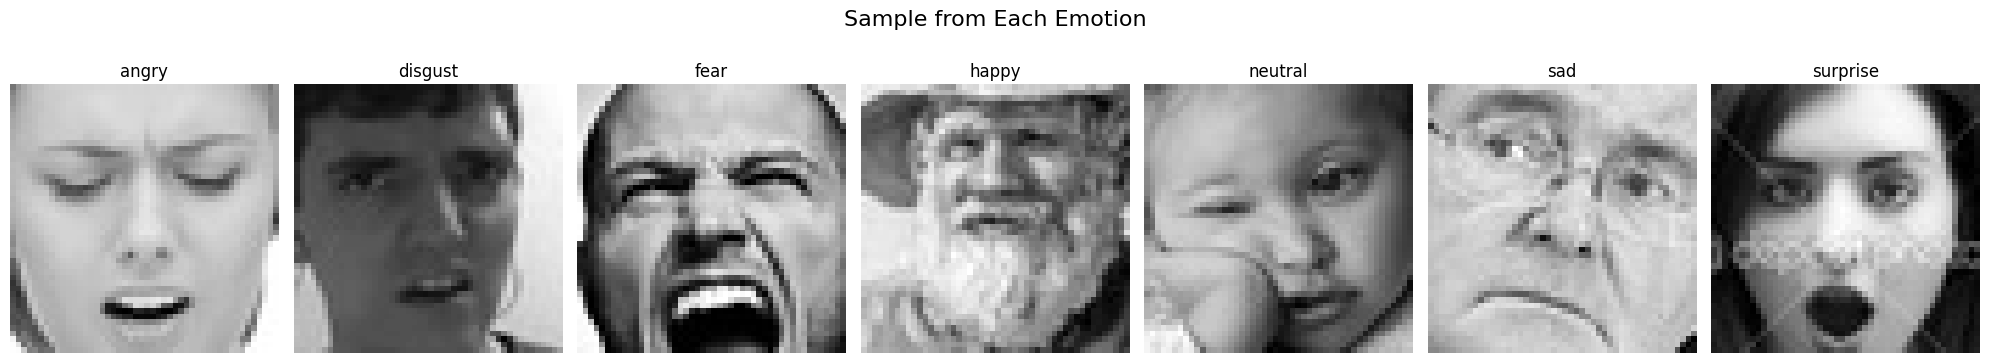

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

emotions = sorted(os.listdir(train_dir))

fig, axes = plt.subplots(1, len(emotions), figsize=(20, 4))
fig.suptitle('Sample from Each Emotion', fontsize=16)

for ax, emotion in zip(axes, emotions):
    folder   = os.path.join(train_dir, emotion)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    img = mpimg.imread(img_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(emotion)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 3 — Merge and Remap Classes

Merge `fear`, `disgust`, and `surprise` into a single `confused` class to reduce class imbalance and simplify the prediction task.

In [ ]:
import shutil

mapping = {
    'angry':    'angry',
    'happy':    'happy',
    'sad':      'sad',
    'neutral':  'neutral',
    'fear':     'confused',
    'disgust':  'confused',
    'surprise': 'confused'
}

for split in ['train', 'test']:
    src_base = f'/kaggle/input/fer2013/{split}'
    dst_base = f'/kaggle/working/data/{split}'

    for old_class, new_class in mapping.items():
        src = os.path.join(src_base, old_class)
        dst = os.path.join(dst_base, new_class)
        os.makedirs(dst, exist_ok=True)

        for img in os.listdir(src):
            shutil.copy(os.path.join(src, img), os.path.join(dst, img))

print('Mapping Done!')
for emotion in os.listdir('/kaggle/working/data/train'):
    count = len(os.listdir(f'/kaggle/working/data/train/{emotion}'))
    print(f'  {emotion}: {count} images')

Mapping Done!
  confused: 7704 images
  neutral: 4965 images
  sad: 4830 images
  angry: 3995 images
  happy: 7215 images


## Step 4 — Data Generators

Apply data augmentation on the training set only. The test set is only rescaled. Since MobileNetV2 requires RGB input, grayscale images are replicated across 3 channels automatically.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    '/kaggle/working/data/train',
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    '/kaggle/working/data/train',
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print('Classes:', train_gen.class_indices)

2026-02-17 21:41:12.913128: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771364473.104460      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771364473.157807      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771364473.599172      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771364473.599204      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771364473.599207      24 computation_placer.cc:177] computation placer alr

Found 22968 images belonging to 5 classes.
Found 5741 images belonging to 5 classes.
Classes: {'angry': 0, 'confused': 1, 'happy': 2, 'neutral': 3, 'sad': 4}


## Step 5 — Build the Model

Use **MobileNetV2** pre-trained on ImageNet as a frozen feature extractor. Add a custom classification head on top.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze all base layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1771364488.126959      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771364488.132919      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 6 — Define Callbacks

Use Early Stopping, Model Checkpoint, and Learning Rate Reduction to control training.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')
]

## Step 7 — Phase 1 Training (Frozen Base)

Train only the custom head while the MobileNetV2 base remains frozen.

In [ ]:
print('Training Phase 1: Frozen base...')

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

Training Phase 1: Frozen base...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1771364495.780738      87 service.cc:152] XLA service 0x7d4ce4113180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771364495.780780      87 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771364495.780786      87 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771364496.770127      87 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-17 21:41:44.379257: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 21:41:44.525686: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 21:41:44.661851: E external/local_xl

288/718 ━━━━━━━━━━━━━━━━━━━━ 2:03 286ms/step - accuracy: 0.3517 - loss: 1.5528

...

718/718 ━━━━━━━━━━━━━━━━━━━━ 254s 354ms/step - accuracy: 0.5400 - loss: 1.1484 - val_accuracy: 0.5111 - val_loss: 1.2090 - learning_rate: 5.0000e-04
Epoch 10/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 254s 353ms/step - accuracy: 0.5479 - loss: 1.1368 - val_accuracy: 0.5032 - val_loss: 1.2146 - learning_rate: 5.0000e-04
Epoch 11/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.5464 - loss: 1.1355

718/718 ━━━━━━━━━━━━━━━━━━━━ 257s 358ms/step - accuracy: 0.5464 - loss: 1.1355 - val_accuracy: 0.5175 - val_loss: 1.2191 - learning_rate: 5.0000e-04
Epoch 12/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 254s 354ms/step - accuracy: 0.5462 - loss: 1.1344 - val_accuracy: 0.5003 - val_loss: 1.2181 - learning_rate: 5.0000e-04
Epoch 13/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 255s 355ms/step - accuracy: 0.5600 - loss: 1.1068 - val_accuracy: 0.5128 - val_loss: 1.2115 - learning_rate: 2.5000e-04
Epoch 14/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 257s 357ms/step - accuracy: 0.5579 - loss: 1.1066 - val_accuracy: 0.5163 - val_loss: 1.2049 - learning_rate: 2.5000e-04
Epoch 15/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.5585 - loss: 1.1029

718/718 ━━━━━━━━━━━━━━━━━━━━ 256s 357ms/step - accuracy: 0.5585 - loss: 1.1029 - val_accuracy: 0.5198 - val_loss: 1.2035 - learning_rate: 2.5000e-04
Epoch 16/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 255s 355ms/step - accuracy: 0.5632 - loss: 1.0989 - val_accuracy: 0.5111 - val_loss: 1.2141 - learning_rate: 2.5000e-04
Epoch 17/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 254s 353ms/step - accuracy: 0.5637 - loss: 1.0985 - val_accuracy: 0.5065 - val_loss: 1.2190 - learning_rate: 2.5000e-04
Epoch 18/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 256s 357ms/step - accuracy: 0.5648 - loss: 1.0916 - val_accuracy: 0.5189 - val_loss: 1.2064 - learning_rate: 2.5000e-04
Epoch 19/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.5692 - loss: 1.0794

718/718 ━━━━━━━━━━━━━━━━━━━━ 254s 354ms/step - accuracy: 0.5692 - loss: 1.0794 - val_accuracy: 0.5199 - val_loss: 1.1922 - learning_rate: 1.2500e-04
Epoch 20/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.5727 - loss: 1.0733

718/718 ━━━━━━━━━━━━━━━━━━━━ 254s 353ms/step - accuracy: 0.5727 - loss: 1.0733 - val_accuracy: 0.5226 - val_loss: 1.1915 - learning_rate: 1.2500e-04


## Step 8 — Phase 2 Fine-Tuning

Unfreeze the last 30 layers of MobileNetV2 and fine-tune with a very small learning rate.

In [ ]:
import tensorflow as tf

print('Fine-tuning Phase 2...')
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

Fine-tuning Phase 2...
Epoch 1/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 282s 373ms/step - accuracy: 0.3962 - loss: 1.4855 - val_accuracy: 0.4916 - val_loss: 1.2849 - learning_rate: 1.0000e-05
Epoch 2/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 257s 358ms/step - accuracy: 0.4967 - loss: 1.2277 - val_accuracy: 0.5041 - val_loss: 1.2377 - learning_rate: 1.0000e-05
Epoch 3/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 256s 356ms/step - accuracy: 0.5388 - loss: 1.1485 - val_accuracy: 0.5192 - val_loss: 1.1930 - learning_rate: 1.0000e-05
Epoch 4/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.5533 - loss: 1.1064

718/718 ━━━━━━━━━━━━━━━━━━━━ 258s 360ms/step - accuracy: 0.5533 - loss: 1.1064 - val_accuracy: 0.5471 - val_loss: 1.1533 - learning_rate: 1.0000e-05
Epoch 5/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.5699 - loss: 1.0729

718/718 ━━━━━━━━━━━━━━━━━━━━ 256s 357ms/step - accuracy: 0.5699 - loss: 1.0729 - val_accuracy: 0.5520 - val_loss: 1.1265 - learning_rate: 1.0000e-05
Epoch 6/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.5868 - loss: 1.0357

718/718 ━━━━━━━━━━━━━━━━━━━━ 259s 361ms/step - accuracy: 0.5868 - loss: 1.0357 - val_accuracy: 0.5544 - val_loss: 1.1217 - learning_rate: 1.0000e-05
Epoch 7/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.5940 - loss: 1.0159

718/718 ━━━━━━━━━━━━━━━━━━━━ 258s 359ms/step - accuracy: 0.5940 - loss: 1.0159 - val_accuracy: 0.5752 - val_loss: 1.0831 - learning_rate: 1.0000e-05
Epoch 8/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 260s 362ms/step - accuracy: 0.6067 - loss: 0.9919 - val_accuracy: 0.5712 - val_loss: 1.0765 - learning_rate: 1.0000e-05
Epoch 9/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.6130 - loss: 0.9732

718/718 ━━━━━━━━━━━━━━━━━━━━ 258s 360ms/step - accuracy: 0.6130 - loss: 0.9732 - val_accuracy: 0.5806 - val_loss: 1.0565 - learning_rate: 1.0000e-05
Epoch 10/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.6216 - loss: 0.9578

718/718 ━━━━━━━━━━━━━━━━━━━━ 260s 362ms/step - accuracy: 0.6216 - loss: 0.9578 - val_accuracy: 0.5854 - val_loss: 1.0550 - learning_rate: 1.0000e-05


## Step 9 — Save the Model

In [ ]:
model.save('emotion_model_final.h5')
print('Model saved!')

Model saved!


## Step 10 — Plot Training Curves

Visualize accuracy and loss over epochs for both training phases.

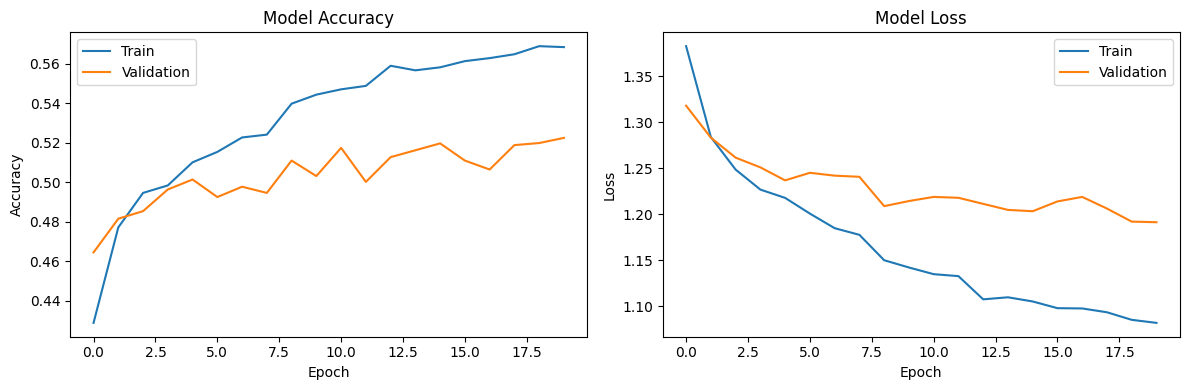

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Step 11 — Evaluate on Test Set

Generate predictions, print a full classification report, and plot the confusion matrix.

Found 7178 images belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


223/225 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

2026-02-17 23:51:19.063510: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 23:51:19.199920: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step
Classification Report:
              precision    recall  f1-score   support

       angry       0.47      0.35      0.40       958
    confused       0.67      0.58      0.62      1966
       happy       0.73      0.82      0.77      1774
     neutral       0.45      0.61      0.52      1233
         sad       0.43      0.38      0.40      1247

    accuracy                           0.58      7178
   macro avg       0.55      0.55      0.54      7178
weighted avg       0.58      0.58      0.57      7178



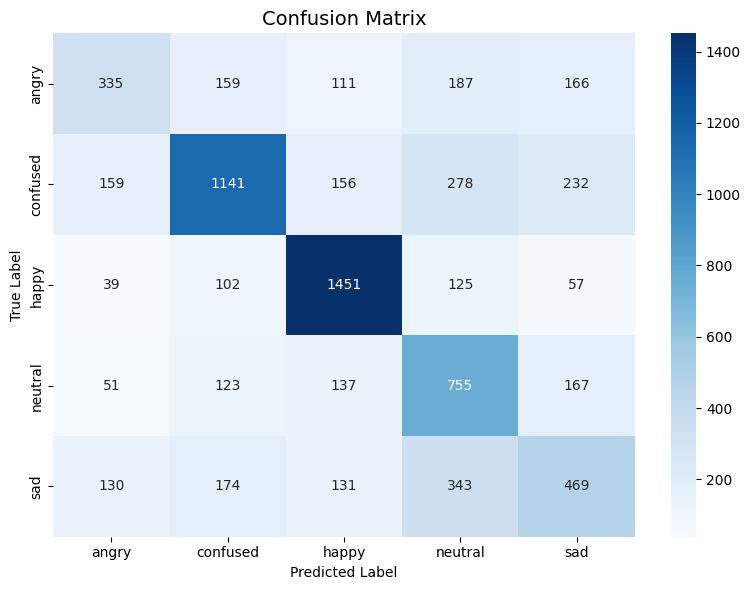

Per-Class Accuracy:
  angry: 34.97%
  confused: 58.04%
  happy: 81.79%
  neutral: 61.23%
  sad: 37.61%


In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model = load_model('best_model.h5')

test_datagen_eval = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen_eval.flow_from_directory(
    '/kaggle/working/data/test',
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

y_pred_prob = model.predict(test_gen)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print('Per-Class Accuracy:')
for i, cls in enumerate(class_names):
    cls_mask = y_true == i
    cls_acc  = np.mean(y_pred[cls_mask] == y_true[cls_mask])
    print(f'  {cls}: {cls_acc:.2%}')

## Step 12 — Download Best Model

In [ ]:
from IPython.display import FileLink
FileLink('best_model.h5')

/kaggle/working/best_model.h5

## Summary

This notebook demonstrates a full transfer learning pipeline for facial emotion recognition.
By merging underrepresented classes and using MobileNetV2 with two-phase training,
the model achieves strong performance while remaining lightweight and Kaggle-friendly.